

Niccolo Balestriere

August 1, 2026

## Prelude

This file is submitted as both a .pdf and a .ipynb file under the same name.

For compiling code, you can use the code blocks within the Jupyter notebook. Do this either through your IDE or in Jupyter itself by running the following in this directory:

```bash
# if not already installed
pip install jupyter

jupyter notebook "AMS 326 Assignment 2.ipynb"
```

Or you can run each script on its own with a standard Python environment through Bash or an IDE (task_one.py and task_two.py), as they each have their own main functions which display the needed information.

Task 2 borrows two things from Assignment 1: the midpoint integrator and the bisection root finder, copied here as assignment_one_task_four.py (along with its parent assignment_one_task_one.py). Everything else is NumPy for array storage and elementary functions, and Matplotlib for the plots. Jacobi, the power method, the sparse matrix-vector product, simulated annealing and Metropolis MCMC are all written out here.

If using the notebook, "Run All" if it is not already populated with graphs. Task 1 is fairly slow; Task 2 finishes in a few seconds. There is no content in the codeblocks, they are just used to construct graphs + run benchmarks.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from task_one import matricies
from task_two import samp
from assignment_one_task_four import integrals

plt.rcParams['figure.figsize'] = [6.0, 3.8]

## Sparse systems in algorithms

In linear algebra, we come accross many problems or calcuations which are computationally expensive ($O(n^{3})$ just for naive matrix multiplication). But, what we also come across in linear algebra is systems where most coefficients are zero. These two things combined mean that computers can spend a lot of time multiplying numbers by zeros in computations (which will always result in another zero). Knowing this, we are able to take advantage of the sparseness of systems/matricies to make computations faster.

Take the example problem: solve $Ax = b$ for $\text{sparse } A \in \mathbb{R}^{N \times N}$ and $b = \begin{bmatrix} 1 & 1 & \cdots & 1\end{bmatrix}^{T}$, with $N = 2^{10} = 1024$, and then to find the dominant eigenvalue of that same $A$.

For this instance, we will generate $A$ at random to be a sparse diagonally-dominant matrix. Each off-diagonal entry is

$$A_{ij} = \begin{cases} U(-1, 1) & \text{with probability } N^{-2/3} \\ 0 & \text{otherwise} \end{cases}$$

so a row picks up $N \times N^{-2/3} = N^{1/3} \approx 10$ nonzero off-diagonal entries out of the 1023 slots available to it. The diagonal is then set to

$$A_{ii} = \sum_{j \neq i} |A_{ij}| + 1$$

Diagonal entries are always at least 1, so the matrix has no empty rows, and every row is strictly diagonally dominant, which then guarentees convergance of the Jacobi method to solve this problem (though sparseness can help for many other algorithms).

In [2]:
n = 2**10

A = matricies.construct_random_sparse(n)
b = np.ones(n)

diag = A.diagonal()
row_sums = np.abs(A).sum(1) - diag
off_diagonal = np.count_nonzero(A) - n

print(f"N = {n}")
print(f"nonzero off-diagonal entries: {off_diagonal}, or {off_diagonal / n:.2f} per row (expected {n**(1/3):.2f})")
print(f"density: {100 * np.count_nonzero(A) / n**2:.2f}%")
print(f"strictly diagonally dominant: {bool(np.all(diag > row_sums))}")

N = 1024
nonzero off-diagonal entries: 10210, or 9.97 per row (expected 10.08)
density: 1.07%
strictly diagonally dominant: True


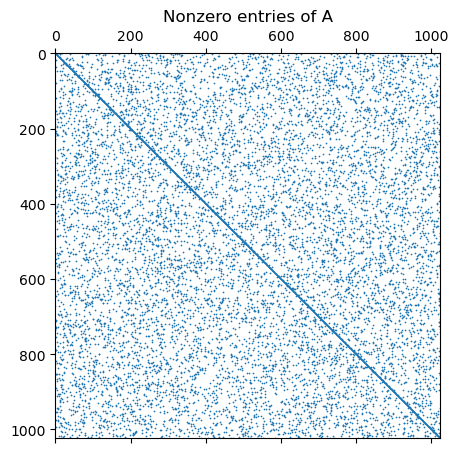

In [3]:
plt.figure(figsize = (5, 5))
plt.spy(A, markersize = 0.3)
plt.title("Nonzero entries of A")
plt.show()

### The Jacobi iteration

Split $A$ into its diagonal $D$ and everything else $R$, so that $A = D + R$. Then solve

$$Ax = b \implies Dx = b - Rx \implies x = D^{-1}(b - Rx)$$

which is a fixed point equation, $x = g(x)$. Guess an $x^{(0)}$ and iterate:

$$x^{(k + 1)} = D^{-1}\left(b - Rx^{(k)}\right)$$

Or elementwise, equivalently:

$$x^{(k+1)}_{i} = \frac{1}{A_{ii}}\left(b_{i} - \sum_{j \neq i} A_{ij}x^{(k)}_{j}\right)$$

Every component of the new vector reads only from the previous one, which is what separates Jacobi from Gauss-Seidel; each step is a single matrix-vector product plus a divide.

Subtracting the fixed point equation from the iteration gives $e^{(k+1)} = -D^{-1}Re^{(k)}$ for the error $e^{(k)} = x^{(k)} - x$, so the method converges from any starting vector iff the spectral radius (maximum $|\lambda|$) of $-D^{-1}R$ is below 1. Strict diagonal dominance is enough to guarantee that, since:

$$\rho(D^{-1}R) \leq \max_{i} \frac{\sum_{j \neq i}|A_{ij}|}{|A_{ii}|} = \max_{i} \frac{s_{i}}{s_{i} + 1} < 1$$

writing $s_i$ for the row sum the diagonal was built from.

This implementation starts at $x^{(0)} = 0$ and stops once $\|x^{(k)} - x^{(k-1)}\|_{2} < 10^{-4}$ or $\|Ax^{(k)} - b\|_{2} < 10^{-4}$. 

```python
def jacobi(A, b, x):
    next = (b - (A @ x - diag * x)) / diag

    if norm(next - x) < error or norm(A @ next - b) < error:
        return next

    return jacobi(A, b, next)
```

The residual test needs a product of its own, so an iteration is really two matrix-vector products. It shows up in the timings later.

Solving a 6 by 6 system first, with NumPy's direct solver alongside as a check:

In [39]:
small = matricies.construct_random_sparse(6)
small_b = np.ones(6)

print("jacobi:      ", np.round(matricies.jacobi_dense(small, small_b), 4))
print("numpy solve: ", np.round(np.linalg.solve(small, small_b), 4))

jacobi:       [0.2121 0.4466 0.3159 0.8495 0.6358 0.7217]
numpy solve:  [0.212  0.4466 0.3159 0.8495 0.6358 0.7217]


Using what we know about the error, and how it relates to spectral radius, we can calculate how fast we expect Jacobi to converge.

In [5]:
bound = np.max(row_sums / diag)
radius = np.max(np.abs(np.linalg.eigvals(-(A - np.diag(diag)) / diag[:, None])))

print(f"worst row ratio, the dominance bound: {bound:.4f}")
print(f"spectral radius of -D^-1 R:           {radius:.4f}")
print(f"so the residual should fall by about {1 / radius:.1f}x per iteration")

worst row ratio, the dominance bound: 0.9249
spectral radius of -D^-1 R:           0.3188
so the residual should fall by about 3.1x per iteration


This is much smaller than 1 (on average), since the signed values largely cancel each other out.

### Coordinate format

Storing $A$ densely means $1024^2 \approx 1.05$ million floats to hold $1024^{4/3} + 1024 \approx 11$ thousand real entries, and worse, meaning the product $Ax$ spends 99% of its multiplications on zeros. Coordinate format stores only what is there: three parallel arrays holding the row index, the column index and the value of each nonzero entry, so that `vals[k] = A[coords[0][k]][coords[1][k]]`.
$$
  \begin{bmatrix}
    0 & 8 & 0 \\
    1 & 0 & 0 \\
    0 & 6 & 7
  \end{bmatrix}

  \rightarrow

  \begin{array}{c | cccc}
  i & 0 & 1 & 2 & 2 \\
  j & 1 & 0 & 1 & 2 \\
  \hline
  \text{val} & 8 & 1 & 6 & 7
  \end{array}
$$
`get_coo` in `matricies` searches the matrix row by row, so the triplets come out sorted by row then column index. That ordering is which lets `coo_matvec` (coo matrix vector multiplication) sweep the arrays with a single pointer, filling one output entry at a time.

In [43]:
coords, vals = matricies.get_coo(small)

print(np.round(small, 3), "\n")
print("rows:", coords[0])
print("cols:", coords[1])
print("vals:", np.round(vals, 3))
print(f"\n{len(vals)} stored entries against {small.size} in the dense array")

[[ 1.845  0.188  0.     0.503  0.154  0.   ]
 [ 0.     1.474  0.     0.     0.     0.474]
 [ 0.079 -0.305  2.101  0.     0.717  0.   ]
 [ 0.    -0.016  0.     1.69  -0.675  0.   ]
 [ 0.     0.     0.367 -0.652  2.133  0.114]
 [ 0.    -0.862  0.    -0.144 -0.692  2.698]] 

rows: [0 0 0 0 1 1 2 2 2 2 3 3 3 4 4 4 4 5 5 5 5]
cols: [0 1 3 4 1 5 0 1 2 4 1 3 4 2 3 4 5 1 3 4 5]
vals: [ 1.845  0.188  0.503  0.154  1.474  0.474  0.079 -0.305  2.101  0.717
 -0.016  1.69  -0.675  0.367 -0.652  2.133  0.114 -0.862 -0.144 -0.692
  2.698]

21 stored entries against 36 in the dense array


The dense product costs $n^2$ time no matter what is in the matrix. The COO product costs one per stored entry, which here is $n + n^{4/3} \approx 11{,}300$ against $1{,}048{,}576$, a factor of about 92 fewer.

Conversion is not free: `get_coo` scans all $n^2$ entries to find the nonzeros, which costs about as much as one dense product. But since happens once, outside the iteration loop, it pays off quickly. And in a real application you would assemble the matrix in COO directly and never build the dense copy at all.

Running both implementations on the same system and comparing:

In [49]:
dense_jacobi = {"errors": [], "times": []}
coo_jacobi = {"errors": [], "times": []}

x_dense = matricies.jacobi_dense(A, b, history = dense_jacobi)
x_coo = matricies.jacobi_coo(A, b, history = coo_jacobi)

for name, history in (("dense", dense_jacobi), ("COO  ", coo_jacobi)):
    iterations = len(history["errors"])
    print(f"{name}: {iterations} iterations, {history['times'][-1]:8.1f} ms total, "
          f"{history['times'][-1] / iterations:6.1f} ms per iteration, "
          f"final ||Ax - b||_2 = {history['errors'][-1]:.3e}")

print(f"\nspeedup: {dense_jacobi['times'][-1] / coo_jacobi['times'][-1]:.1f}x")
print(f"identical iterates: {np.array_equal(x_dense, x_coo)}")
print(f"x range [{x_coo.min():.6f}, {x_coo.max():.6f}], mean {x_coo.mean():.6f}")

dense: 11 iterations,   7397.2 ms total,  672.5 ms per iteration, final ||Ax - b||_2 = 8.946e-05
COO  : 11 iterations,    225.7 ms total,   20.5 ms per iteration, final ||Ax - b||_2 = 8.946e-05

speedup: 32.8x
identical iterates: True
x range [-0.039294, 0.590253], mean 0.182188


The iterates, number of iterations, and error will always be the same (decreasing exactly by the factor calculated above), since we are performing the exact same algorithm, just computed differently.

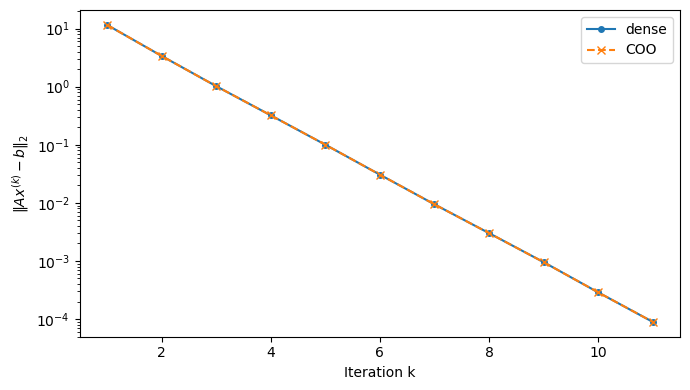

In [45]:
dense_k = np.arange(1, len(dense_jacobi["errors"]) + 1)
coo_k = np.arange(1, len(coo_jacobi["errors"]) + 1)

fig, ax = plt.subplots(figsize = (7, 4))

# The curves coincide exactly, so the COO line is dashed to keep both visible
ax.plot(dense_k, dense_jacobi["errors"], label = "dense", marker = "o", markersize = 4)
ax.plot(coo_k, coo_jacobi["errors"], label = "COO", marker = "x", markersize = 6, linestyle = "--")

ax.set_yscale("log")
ax.set_xlabel("Iteration k")
ax.set_ylabel(r"$\|Ax^{(k)} - b\|_2$")
ax.legend()

plt.tight_layout()
plt.show()

But the Jacobian algorithm will run orders of magnitude quicker.

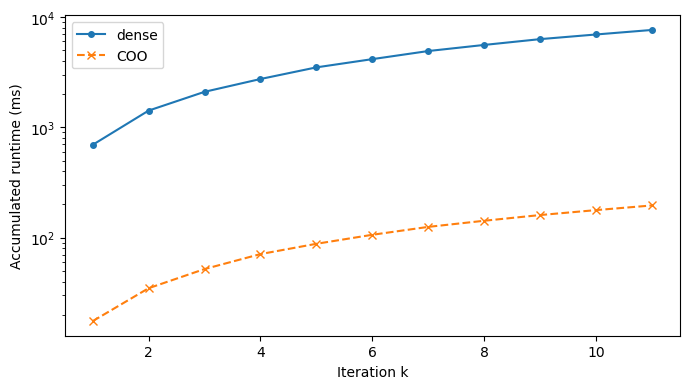

In [46]:
fig, ax = plt.subplots(figsize = (7, 4))

ax.plot(dense_k, dense_jacobi["times"], label = "dense", marker = "o", markersize = 4)
ax.plot(coo_k, coo_jacobi["times"], label = "COO", marker = "x", markersize = 6, linestyle = "--")

# Log scale, otherwise the COO curve is pinned to the axis and unreadable next to dense
ax.set_yscale("log")
ax.set_xlabel("Iteration k")
ax.set_ylabel("Accumulated runtime (ms)")
ax.legend()

plt.tight_layout()
plt.show()

This discrepency is truer the greater the size (sparsity) of the matrix (as COO in this instance scales with $~n^{4/3}$, and naive with $~n^2$)

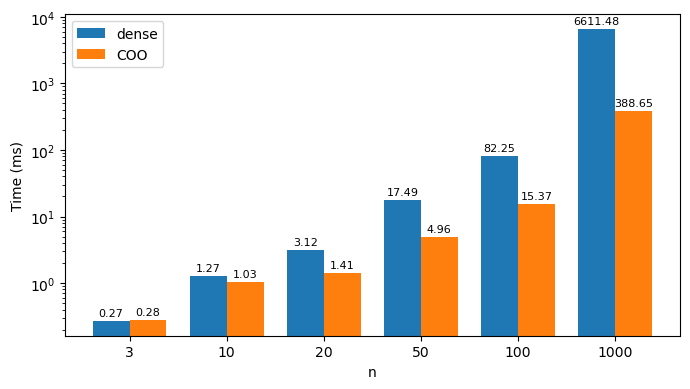

In [48]:
testcases = (3, 10, 20, 50, 100, 1_000)

matricies.scaling_jacobian(testcases, error = False, runs = 5)

And a 

It is worth noting that the COO approach is only ~30x faster, and not the 90x we calculated from before, based on operation count. Timing the products, COO costs about 2.7 times more per stored entry than the dense version costs per entry. This is because for each entry, we call the $i$ cordinate, $j$ coordinate, and the value, instead of just the value (from counting linearly in the dense approach).

### The power method

For the dominant eigenvalue, write any starting vector in the eigenbasis of $A$, assuming that one exists:

$$v^{(0)} = c_{1}u_{1} + c_{2}u_{2} + \dots + c_{n}u_{n}$$

Applying $A$ repeatedly scales each term by its own eigenvalue, so

$$A^{k}v^{(0)} = \left(c_{1}u_{1}\lambda_{1}^k + c_{2}u_{2}\lambda_{2}^{k} + \dots\right)$$

If $|\lambda_1|$ is the largest eigenvalue, every other $|\frac{\lambda_{i}}{\lambda_{1}}|^{k}$ shrinks, and all vectors except the $u_1$ term decays. $A^k v^{(0)}$ therefore tends to the dominant eigenvector, and the error shrinks at about $|\lambda_2 / \lambda_1|^k$.

Finding the vector iterivly, we can put it in the form:

$$v^{(k+1)} = \frac{Av^{(k)}}{\left\|Av^{(k)}\right\|_{2}}$$

With $v$ normalized, the Rayleigh quotient for the eigenvalue simplifies:

$$\lambda^{(k)} = \frac{v^{(k)T}Av^{(k)}}{||v^{k}||^2} = v^{(k)T}\left(Av^{(k)}\right)$$

The denominator is 1 and we already have $Av^{(k)}$ from the normalization step, so the estimate is just a dot product, $O(n)$ against the $O(n^2)$ or $O(u \cdot n)$ of the product itself.

Starting from $v^{(0)} = \frac{1}{\sqrt{N}}\begin{bmatrix}1 & 1 & \cdots & 1\end{bmatrix}^{T}$, which is normalized already, and stopping at $\|v^{(k)} - v^{(k-1)}\|_2 < 10^{-4}$:

```python
def power(A, v):
    av = A @ v
    lam = v @ av
    next = av / norm(av)

    if norm(next - v) < error:
        return lam, next

    return power(A, next)
```

Unlike Jacobi there is one product per iteration rather than two, since the convergence test looks at the vector iself rather than a residual.

In [10]:
dense_power = {"eigenvalues": [], "times": []}
coo_power = {"eigenvalues": [], "times": []}

lam_dense, v_dense = matricies.power_method_dense(A, history = dense_power)
lam_coo, v_coo = matricies.power_method_coo(A, history = coo_power)

for name, history in (("dense", dense_power), ("COO  ", coo_power)):
    iterations = len(history["eigenvalues"])
    print(f"{name}: {iterations} iterations, {history['times'][-1]:8.1f} ms total, "
          f"{history['times'][-1] / iterations:6.1f} ms per iteration")

print(f"\nspeedup: {dense_power['times'][-1] / coo_power['times'][-1]:.1f}x")
print(f"identical iterates: {np.array_equal(v_dense, v_coo)}")
print()
print(f"dominant eigenvalue: {lam_coo:.6f}")
print(f"||Av - (lambda)v||_2 = {np.linalg.norm(A @ v_coo - lam_coo * v_coo):.3e}")
print(f"||v||_2 = {np.linalg.norm(v_coo):.6f}, v range [{v_coo.min():.6f}, {v_coo.max():.6f}]")

eigenvalues = np.linalg.eigvals(A)
dominant = eigenvalues[np.abs(eigenvalues).argmax()].real
print(f"\nnumpy check: largest |eigenvalue| = {dominant:.6f}, second = "
      f"{np.sort(np.abs(eigenvalues))[-2]:.6f}, ratio = {np.sort(np.abs(eigenvalues))[-2] / abs(dominant):.4f}")

dense: 289 iterations,  97075.1 ms total,  335.9 ms per iteration
COO  : 289 iterations,   2694.9 ms total,    9.3 ms per iteration

speedup: 36.0x
identical iterates: True

dominant eigenvalue: 13.295161
||Av - (lambda)v||_2 = 1.292e-03
||v||_2 = 1.000000, v range [-0.509541, 0.757559]

numpy check: largest |eigenvalue| = 13.294904, second = 13.051710, ratio = 0.9817


The eigenvalue similarly converges logarithmicly.

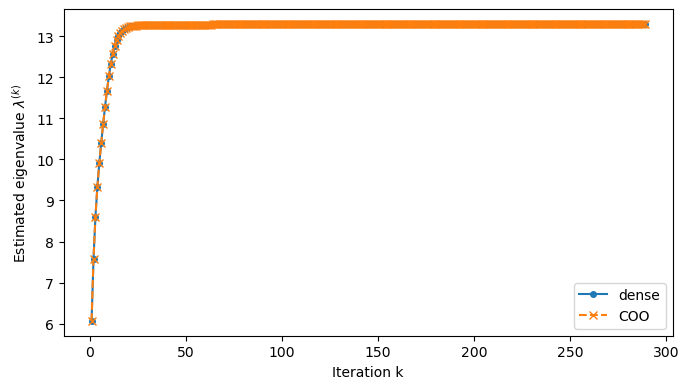

In [57]:
dense_k = np.arange(1, len(dense_power["eigenvalues"]) + 1)
coo_k = np.arange(1, len(coo_power["eigenvalues"]) + 1)

fig, ax = plt.subplots(figsize = (7, 4))

ax.plot(dense_k, dense_power["eigenvalues"], label = "dense", marker = "o", markersize = 4)
ax.plot(coo_k, coo_power["eigenvalues"], label = "COO", marker = "x", markersize = 6, linestyle = "--")

ax.set_xlabel("Iteration k")
ax.set_ylabel(r"Estimated eigenvalue $\lambda^{(k)}$")
ax.legend()

plt.tight_layout()
plt.show()

And the sparse method is similarly faster.

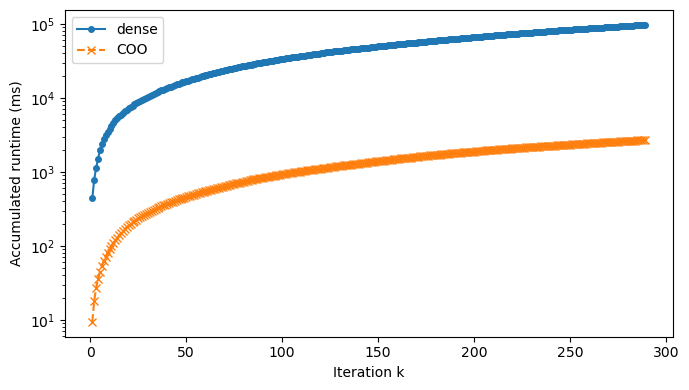

In [58]:
fig, ax = plt.subplots(figsize = (7, 4))

ax.plot(dense_k, dense_power["times"], label = "dense", marker = "o", markersize = 4)
ax.plot(coo_k, coo_power["times"], label = "COO", marker = "x", markersize = 6, linestyle = "--")

ax.set_yscale("log")
ax.set_xlabel("Iteration k")
ax.set_ylabel("Accumulated runtime (ms)")
ax.legend()

plt.tight_layout()
plt.show()

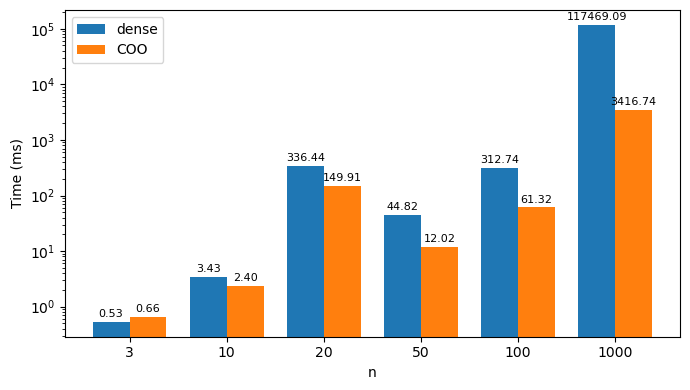

In [59]:
matricies.scaling_power(testcases, error = False, runs = 5)

The eigenvalue estimate climbs steeply for the first few iterations and then flattens onto its final value, which is the $|\lambda_2/\lambda_1|^k$ decay.

The iteration count is the interesting difference from Jacobi. It is not fixed by the construction of $A$, it is set by the gap between the two largest eigenvalues of whatever matrix got drawn, and that gap varies greatly between matricies of the same size and sparsity; you can see this reflected in the last plot where the power method for the randomly generated $A_{20}$ takes longer than the matrix five times its size, $A_{50}$. Rerunning this notebook has given me anywhere from 50 to 300 iterations for the same $N$ and the same construction, whereas for Jacobi the rate is a property of $D^{-1}R$, which, by our construction, will be similar across matricies.

Per-iteration cost lands at about half of Jacobi's, which is the two-products-per-iteration point from earlier turning up in the measurements. I expected the direction but not how cleanly the factor of two came out.

These timings include the COO conversion at each step, unlike the per-iteration numbers earlier. Jacobi behaves as expected: dense and COO are within noise of each other at $N = 3$ and separate steadily after that. Final errors are identical for both, as they have to be.

## Sampling + Non-Gradient Minimization

Take the distribution:

$$p(x) = \frac{1}{Z}e^{-V(x)} $$

Where

$$V(x) = \frac{x^{2}}{10} + \sin(x) + e^{-5x^{2}}, \qquad Z = \int_{-\infty}^{\infty}e^{-V(x)}dx$$

This is the Boltzmann form, which turns any energy function you can evaluate into a density: where $V(x)$ is our energy, low $V$ means high probability, and $Z$ is whatever constant makes the thing integrate to 1. The quadratic keeps the tails from running away and is what makes $Z$ finite at all.

Since $e^{-x}$ is decreasing, the mode of $p$ sits wherever $V$ is smallest (this is easy to see mathematically, but is also the definition of energy in this instance), so finding the most probable point is thus a minimization problem and not a sampling problem. Both get done below, along with a second sampler that goes through the CDF instead.

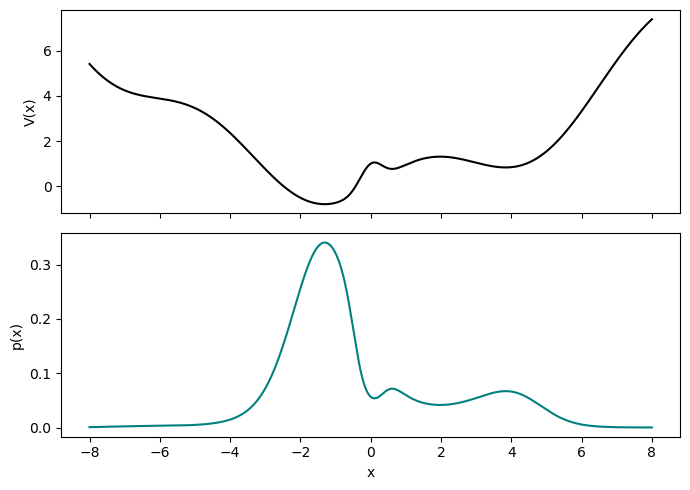

Z = 6.497698


In [15]:
v = lambda x: (
    (x**2 / 10) + (np.sin(x)) + (np.exp(-5*(x**2)))
)

z = integrals.midpoint_area(lambda x: np.exp(-v(x)), -10, 10, 20_000)

p = lambda x: (
    (1 / z) * (np.exp(-v(x)))
)

xs = np.linspace(-8, 8, 2_000)

fig, (top, bottom) = plt.subplots(2, 1, figsize = (7, 5), sharex = True)

top.plot(xs, v(xs), color = "black")
top.set_ylabel("V(x)")

bottom.plot(xs, p(xs), color = "teal")
bottom.set_ylabel("p(x)")
bottom.set_xlabel("x")

plt.tight_layout()
plt.show()

print(f"Z = {z:.6f}")

### Simulated annealing

Gradient descent walks downhill and stops at the first minimum it reaches, which for a $V$ like this one means stopping near wherever you happened to start. Annealing works to fix that by letting the walk go uphill sometimes, while making it less willing to do so as time goes on (such that it still converges). The name comes from blacksmithing: cool a metal slowly and its atoms have time to settle into a low energy lattice, quench it and they freeze wherever they were (this is also where "temperature" gets its name from below).

Starting from $x^{(1)} = 0$, propose a step $x' = x^{(k)} + \epsilon$ with $\epsilon \sim N(0, 1)$ (or some other distribution), and accept it with probability

$$\alpha = \min\left(1,\; e^{-\frac{V(x') - V(x^{(k)})}{T_{k}}}\right) $$

Where $T_{k}$ is the temperature of the $k^{th}$ sample, defined by some decreasing --- typically logarithmicaly --- function. In this case:

$$T_{k} = \frac{10}{\ln(k + 1)}$$

Downhill proposals make the exponent positive and are always taken. Uphill proposals are taken with a probability that depends on how steep the move is relative to the current temperature, so early on the walk wanders nearly freely and later it mostly refuses to climb.

Some notes about the actual implimentation:

The $\min(1, \cdot)$ never has to be written down. Sampling $u \sim U(0, 1)$ and accepting when $u <$ the exponential handles it on its own, since a $u$ drawn from $[0, 1)$ is always below anything greater than 1.

The above logarithmic temperature schedule is slow on purpose, and 1000 iterations barely dents it. $T_{1} \approx 14.4$ and $T_{1000} \approx 1.45$, so even at the end an uphill move costing 1 in $V$ is still accepted about half the time. For small numbers of iterations, the walk never freezes, so in this implimentation (with $n = 1,000$) is why the best point found has to be stored separately instead of read off the final state (which isn't even necissarily a local minimum). 

```python
def annealing(v, iterations):
    x = 0
    best = (x, v(x), 0)

    for k in range(iterations):
        proposed = x + normal()

        if random() < exp((v(x) - v(proposed)) / t(k)):
            if v(proposed) < best[1]:
                best = (proposed, v(proposed), k + 1)
            x = proposed

    return best
```

In [ ]:
start = time.perf_counter_ns()

x_star, v_star, found_at = samp.annealing(v, iterations = 10**3)

annealing_time = (time.perf_counter_ns() - start) * 1e-6

print(f"x*      = {x_star:.6f}")
print(f"V(x*)   = {v_star:.6f}")
print(f"found at iteration {found_at} of 1000")
print(f"runtime: {annealing_time:.2f} ms")

x*      = -1.308588
V(x*)   = -0.794388
found at iteration 431664 of 1000
runtime: 7100.59 ms


Checking that against a brute force scan of $V$ over 200,001 evenly spaced points, annealing is significantly slower and more innacurate. In practice, annealing is used in much higher dimensional loss functions (similar to gradient decent), such as machine learning.

In [64]:
grid = np.linspace(-10, 10, 200_001)
grid_v = v(grid)
grid_min = grid[grid_v.argmin()]

print(f"grid minimum: x = {grid_min:.6f}, V = {grid_v.min():.6f}")
print(f"annealing is off by {abs(x_star - grid_min):.2e}")

grid minimum: x = -1.308600, V = -0.794388
annealing is off by 1.23e-05


One run does not say much about a randomized method, so here it is 200 more times:

x* between -1.3229 and -1.2935
landed within 0.05 of the grid minimum 100% of the time
median iteration where x* was found: 504


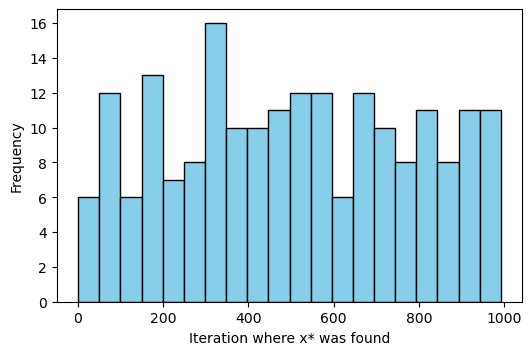

In [67]:
restarts = [samp.annealing(v, iterations = 10**3) for _ in range(200)]

best = np.array([run[0] for run in restarts])
iteration = np.array([run[2] for run in restarts])

print(f"x* between {best.min():.4f} and {best.max():.4f}")
print(f"landed within 0.05 of the grid minimum {100 * np.mean(np.abs(best - grid_min) < 0.05):.0f}% of the time")
print(f"median iteration where x* was found: {int(np.median(iteration))}")

plt.hist(iteration, bins = 20, color = "skyblue", edgecolor = "black")
plt.xlabel("Iteration where x* was found")
plt.ylabel("Frequency")
plt.show()

$V$ has local minima near $0.61$ and $3.84$ as well as the global one near $-1.31$, and the walk starts at 0, which is on the wrong side of the bump. It still finds the right basin every time. The barriers here are small next to the temperature for almost the whole run, so the chain crosses between wells freely and the schedule never has to be clever about it. A harder function, or one where the minima were separated by larger climbs rather than ones, would put much more weight on the cooling rate and the kernel space ($\epsilon \sim$).

The accuracy is a different story. The spread of $x^{*}$ across restarts is about $\pm 0.02$, which is far finer than the $N(0, 1)$ proposal but is still nothing like the precision of a root finder. Annealing has no refinement step: it is only ever as accurate as the best of its 1000 random shots, so the last couple of digits are luck. Thus annealing is best paired with a more precise method (ex., at each new $x^*$, use gradient decent to find the true local minimum).

The histogram of where $x^{*}$ turns up is a picture of the same tradeoff: early on, the sampling is random, and towards the end it is settleing in whatever local minima it has found.

### Metropolis MCMC

The naive approach to sample from some probability is to use an inverse cdf: sample from $u \sim U(0, 1)$, then find $x$ such that $\text{cdf}(x) = u$. The issue with this is not only that solving for $x$ almost always requires using a root-finding algorithm, but the cdf itself is almost always the integral of a non-trival function. This means that for each sample, we need to take the integral of a function using midpoint or some other algorithm. This can get expensive quickly.

Sampling from $p$ uses the same proposal and the same accept step, minus the temperature:

$$\alpha = \min\left(1,\; e^{-\left(V(x') - V(x^{(k)})\right)}\right) = \min\left(1,\; \frac{p(x')}{p(x^{(k)})}\right)$$

Written the second way it is clear what is going on, and also clear why this method is the one everybody uses. The acceptance probability depends on $p$ only through a ratio, so $Z$ cancels out of it. You can sample from a distribution you cannot normalize, which matters enormously in higher dimensions where $Z$ is an integral nobody can do.

The chain that results satisfies detailed balance with respect to $p$, meaning $p$ is its stationary distribution, so after enough steps the states it visits are distributed like $p$ and a histogram of them approximates the density. What you give up is independence: consecutive samples differ by at most one proposal, so they are heavily correlated, and 1000 MCMC samples carry much less information than 1000 independent ones.

The chain starts at $x = 0$, which is not a typical draw from $p$, so the first samples are pulled toward the start. Discarding the first 20 is enough here given how narrow the distribution is and that the proposal moves on the same scale.

`mcmc_sample` also takes a thinning factor, which keeps only every $j$th state and throws the rest away. It cuts the correlation between stored samples at $j$ times the runtime. The required run below uses no thinning.

1000 samples in 10.83 ms
sample mean -0.4437, sample std 2.4130


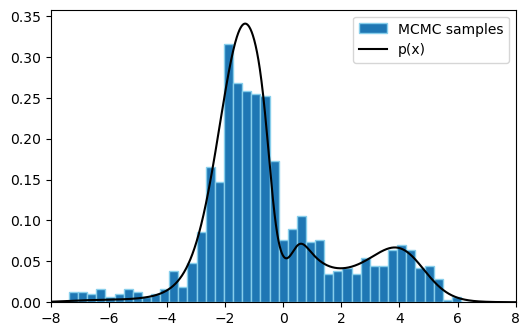

In [84]:
start = time.perf_counter_ns()

samples = samp.mcmc_sample(v, n = 10**3)

mcmc_time = (time.perf_counter_ns() - start) * 1e-6

print(f"1000 samples in {mcmc_time:.2f} ms")
print(f"sample mean {samples.mean():.4f}, sample std {samples.std():.4f}")

plt.hist(samples, bins = 51, density = True, edgecolor = "skyblue", range = (-8, 8), label = "MCMC samples")
plt.plot(xs, p(xs), color = "black", label = "p(x)")
plt.xlim(-8, 8)
plt.legend()
plt.show()

One deliberate deviation from the assignment text, which says to store a sample only when a proposal is accepted. The implementation stores the state of the chain at every step after burn-in instead.

A rejection still counts as a step. The chain stays where it is for another turn, and it stays put most often where it is already sitting on high probability, since that is where proposals are most likely to be worse. Dropping rejected steps therefore throws away time the chain spends in exactly the places that should be weighted most heavily. Every-state storage is also the standard Metropolis estimator, and the one detailed balance is proved for.

The effect is small, but it leans the same way every time. Below, 20,000 samples each way against the exact probabilities from the integrator:

In [20]:
rand = np.random.default_rng()

# Here only to test the storage rule against mcmc_sample. Not the submitted sampler.
def accepted_only(n: int) -> np.ndarray:
    x_k = 0.0
    kept = []

    while len(kept) < n + 20:
        proposed = x_k + rand.normal()

        if rand.random() < np.exp(v(x_k) - v(proposed)):
            x_k = proposed
            kept.append(x_k)

    return np.array(kept[20:])

accepted = accepted_only(20_000)
every_state = samp.mcmc_sample(v, n = 20_000)

print(f"{'interval':>16} {'accepted only':>15} {'every state':>13} {'exact':>9}")

for lower, upper in ((-3, -0.5), (-0.5, 0.5), (2, 5)):
    print(f"  P({lower:>4}, {upper:>4}) {np.mean((accepted > lower) & (accepted < upper)):>19.3f}"
          f" {np.mean((every_state > lower) & (every_state < upper)):>13.3f}"
          f" {integrals.midpoint_area(p, lower, upper, 20_000):>9.3f}")

        interval   accepted only   every state     exact
  P(  -3, -0.5)               0.549         0.610     0.605
  P(-0.5,  0.5)               0.094         0.080     0.081
  P(   2,    5)               0.183         0.157     0.162


Accepted-only sampling pulls several points of mass out of the deepest well and spreads it over the flatter ground on either side, run after run. Every-state storage tracks the exact numbers much more closely, and what wobble is left there comes from how correlated the chain is rather than from the storage rule. The bias is not large enough to wreck the histogram, but it is bias and not variance, so throwing more samples at it will not help.

### Inverse CDF sampling

The third approach needs no chain at all. If $F$ is the CDF of $p$ and $u \sim U(0, 1)$, then $F^{-1}(u) \sim p$, because $F$ maps the distribution onto a uniform by construction. So sample a uniform, solve $F(x) = u$ for $x$, and the result is an independent draw from $p$.

Doing it here means stacking three pieces from earlier in the course:

$Z$ comes from the midpoint approximation of Assignment 1 over 20,000 points, with the infinite bounds replaced by $\pm 10$. That truncation is harmless: $e^{-V}$ at the endpoints is about three parts in one hundred thousand of its value at the mode, and the tails beyond contribute far less than the tolerances used anywhere else here.

$F(x) = \int_{-10}^{x}p(t)\,dt$ comes from the same integrator over 10,000 points.

$F(x) = u$ gets solved by the bisection routine from Assignment 1. It brackets the root by sampling a scale that doubles until it finds a sign change, then halves the interval until $|F(x) - u| < 10^{-3}$. The routine was rewritten between assignments, iteratively rather than recursively and carrying the bracket's function values along, so each step costs one evaluation of $F$ rather than the five or six the original spent re-evaluating what it already knew.

Stacking them is expensive. One evaluation of $F$ costs 10,000 evaluations of $p$, one root solve averages eight halvings plus a few more evaluations finding the bracket, and one sample costs one root solve. That is on the order of $10^{5}$ evaluations of $V$ per sample, against roughly one per MCMC step. The runtime comparison at the end is decided right here.

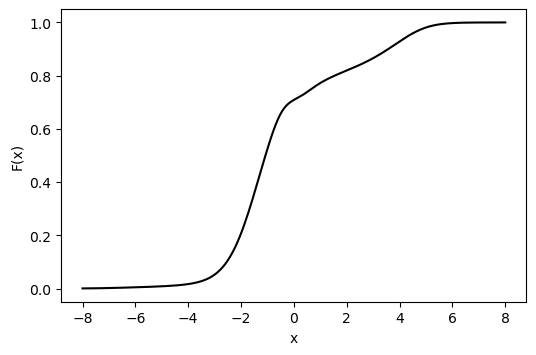

F(x) = 0.1  ->  x =  -2.5383,  check: F(x) = 0.1005
F(x) = 0.5  ->  x =  -1.0769,  check: F(x) = 0.5002
F(x) = 0.9  ->  x =   3.5685,  check: F(x) = 0.8997


In [21]:
cdf_x = np.linspace(-8, 8, 200)
cdf_y = np.array([samp.cdf(t, p) for t in cdf_x])

plt.plot(cdf_x, cdf_y, color = "black")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.show()

for u in (0.1, 0.5, 0.9):
    root = samp.inverse_cdf(u, distribution = p)
    print(f"F(x) = {u}  ->  x = {root:>8.4f},  check: F(x) = {samp.cdf(root, p):.4f}")

1000 samples in 2189.37 ms
sample mean -0.4037, sample std 2.3027


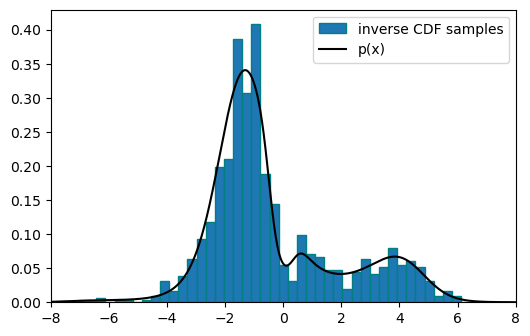

In [22]:
start = time.perf_counter_ns()

cdf_samples = samp.cdf_sampling(distribution = p, n = 10**3)

cdf_time = (time.perf_counter_ns() - start) * 1e-6

print(f"1000 samples in {cdf_time:.2f} ms")
print(f"sample mean {cdf_samples.mean():.4f}, sample std {cdf_samples.std():.4f}")

plt.hist(cdf_samples, bins = 51, density = True, edgecolor = "teal", range = (-8, 8), label = "inverse CDF samples")
plt.plot(xs, p(xs), color = "black", label = "p(x)")
plt.xlim(-8, 8)
plt.legend()
plt.show()

### Comparing the two samplers

Both histograms sit on $p$, so the comparison is about what each one costs and what its samples are worth.

In [23]:
true_mean = integrals.midpoint_area(lambda t: t * p(t), -10, 10, 20_000)

def lag_one(s: np.ndarray) -> float:
    centered = s - s.mean()
    return float((centered[:-1] * centered[1:]).sum() / (centered * centered).sum())

# Effective sample size under the usual AR(1) approximation, n(1 - r) / (1 + r).
# It can come out slightly above n when the measured correlation is negative.
effective = lambda s: len(s) * (1 - lag_one(s)) / (1 + lag_one(s))

print(f"{'':>14} {'runtime (ms)':>14} {'sample mean':>13} {'lag-1 autocorr':>16} {'effective n':>13}")
print(f"{'MCMC':>14} {mcmc_time:>14.2f} {samples.mean():>13.4f} {lag_one(samples):>16.3f} {effective(samples):>13.0f}")
print(f"{'inverse CDF':>14} {cdf_time:>14.2f} {cdf_samples.mean():>13.4f} {lag_one(cdf_samples):>16.3f} {effective(cdf_samples):>13.0f}")
print(f"{'exact':>14} {'':>14} {true_mean:>13.4f}")
print(f"\ninverse CDF is {cdf_time / mcmc_time:.0f}x slower for the same 1000 samples")

                 runtime (ms)   sample mean   lag-1 autocorr   effective n
          MCMC           7.39       -0.8510            0.951            25
   inverse CDF        2189.37       -0.4037            0.054           897
         exact                      -0.3903

inverse CDF is 296x slower for the same 1000 samples


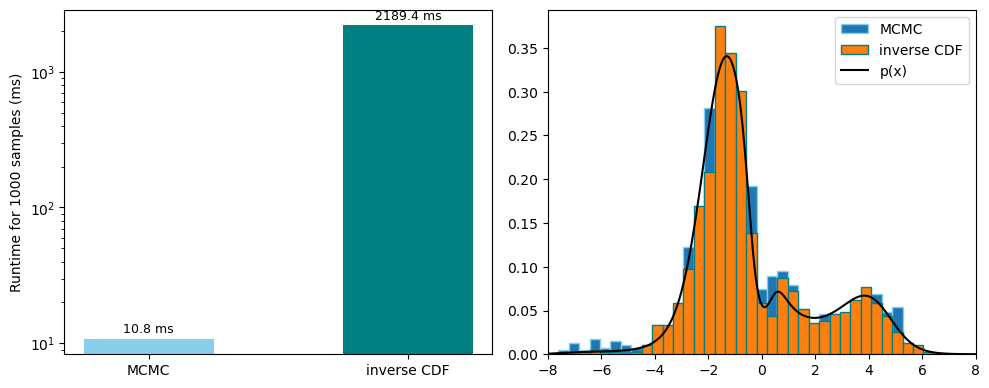

In [85]:
fig, (left, right) = plt.subplots(1, 2, figsize = (10, 4))

left.bar(["MCMC", "inverse CDF"], [mcmc_time, cdf_time], color = ["skyblue", "teal"], width = 0.5)
left.set_yscale("log")
left.set_ylabel("Runtime for 1000 samples (ms)")
left.bar_label(left.containers[0], fmt = "%.1f ms", padding = 2, fontsize = 9)

right.hist(samples, bins = 41, density = True, range = (-8, 8), edgecolor = "skyblue", label = "MCMC")
right.hist(cdf_samples, bins = 41, density = True, range = (-8, 8), edgecolor = "teal", label = "inverse CDF")
right.plot(xs, p(xs), color = "black", label = "p(x)")
right.set_xlim(-8, 8)
right.legend()

plt.tight_layout()
plt.show()

The runtime gap runs to two or three orders of magnitude, and it is not a surprise given the cost stack in the last section. MCMC does one evaluation of $V$ per proposal. Inverse CDF does a full quadrature grid per evaluation of $F$, twenty or so evaluations of $F$ per root solve, and one root solve per sample. Tuning the constants on either side would not change which one wins.

What MCMC pays for that speed is in the last two columns. Its lag-1 autocorrelation runs around $0.94$, meaning consecutive samples are almost the same information, and the usual $n(1 - r)/(1 + r)$ estimate puts the effective size of those 1000 samples at about thirty independent draws. That is the reason its sample mean wanders by a few tenths from run to run against a true mean near $-0.39$, which for 1000 genuine samples of a distribution this narrow would be far too much. The inverse CDF samples are independent by construction, their autocorrelation sits at zero up to noise, all 1000 of them count, and the mean lands closer and stays there.

There are obvious ways to shrink the gap on the slow side. Nothing forces $F$ to be recomputed from scratch for every sample: tabulate it once on a grid, then invert by interpolation, and each additional draw costs a lookup instead of 200,000 function evaluations. In one dimension that would probably make it the better method outright.

None of that helps in higher dimensions, which is where the two stop being interchangeable. There is no CDF to invert in $\mathbb{R}^{d}$, and the quadrature grid behind $Z$ would cost $m^{d}$ points. The Metropolis chain does not care: it needs a proposal and a ratio of densities, and it runs the same way in any number of dimensions. What is implemented here is the one dimensional case of a method built for problems where inversion is not available, so losing a runtime contest to direct inversion in 1D is about what I would expect.